In [1]:
import numpy as np
import geopandas as gpd
import os
from pynhd import NLDI
import dataretrieval.nwis as nwis
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rioxarray as rxr
import shapely
from shapely.geometry import mapping

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create all Basin Shapefiles in gage_ids.csv

I used the USGS python package NLDI Flow Tools to easily dilineate basin off gage id
https://www.usgs.gov/software/nldi-flow-tools

In [11]:
def delineate_basin_from_gage(
    gage_id,
    out_dir="/home/clemasters/EF5-RTI/data/basin_delineations"
):
    """
    Delineate an upstream basin polygon from a USGS stream gage ID.

    Parameters
    ----------
    gage_id : str
        USGS site number, e.g. "06752260"
    out_dir : str
        Folder to save output files

    Returns
    -------
    basin_gdf : geopandas.GeoDataFrame
        Upstream basin polygon
    site_gdf : geopandas.GeoDataFrame
        Gage point
    """

    os.makedirs(out_dir, exist_ok=True)

    # Make sure gage_id is a clean string
    gage_id = str(gage_id).strip()

    # 1) Pull site metadata from USGS NWIS
    site = nwis.get_info(sites=gage_id)[0]

    if site.empty:
        raise ValueError(f"No USGS site metadata found for gage {gage_id}")

    # USGS site metadata commonly contains decimal latitude/longitude
    lat = float(site.iloc[0]["dec_lat_va"])
    lon = float(site.iloc[0]["dec_long_va"])

    # Build gage point GeoDataFrame
    site_gdf = gpd.GeoDataFrame(
        site.copy(),
        geometry=gpd.points_from_xy([lon], [lat]),
        crs="EPSG:4326",
    )

    # 2) Delineate basin using NLDI / PyNHD
    nldi = NLDI()

    # Local catchment
    try:
        split_catchment = nldi.get_basins(
            [gage_id],
            fsource="nwissite",
            split_catchment=True,
            simplified=False,
        )
    except Exception:
        split_catchment = None

    # Full upstream basin
    basin_gdf = nldi.get_basins(
        [gage_id],
        fsource="nwissite",
        split_catchment=False,
        simplified=False,
    )

    if basin_gdf is None or basin_gdf.empty:
        raise ValueError(
            f"NLDI did not return a basin for gage {gage_id}. "
            "This can happen for some sites or locations outside supported coverage."
        )

    # Save outputs
    basin_path = os.path.join(out_dir, f"{gage_id}_basin.geojson")
    site_path = os.path.join(out_dir, f"{gage_id}_gage.geojson")
    local_path = os.path.join(out_dir, f"{gage_id}_localcatchment.geojson")

    basin_gdf.to_file(basin_path, driver="GeoJSON")
    site_gdf.to_file(site_path, driver="GeoJSON")

    if split_catchment is not None and not split_catchment.empty:
        split_catchment.to_file(local_path, driver="GeoJSON")

    return basin_gdf, site_gdf

## Just set path to csv with gage ids (make sure column with gage ids is "gage_id")

In [12]:
gage_ids = pd.read_csv(
    "/home/clemasters/EF5-RTI/gages/gage_ids.csv",
    dtype=str
).iloc[:, 0].tolist()

for gage_id in gage_ids:
    try:
        delineate_basin_from_gage(gage_id, out_dir="/home/clemasters/EF5-RTI/data/basin_delineations")
        print(f"Done: {gage_id}")
    except Exception as e:
        print(f"Failed: {gage_id} -> {e}")

Done: 03463300
Done: 04282780


# Clip Basic Files using Basin Shapefile

In [ ]:
import os
from pathlib import Path

import geopandas as gpd
import rasterio
from rasterio.mask import mask


# =============================================================================
# USER INPUTS
# =============================================================================
basin_name = "South_Toe_03463300"

basin_boundary = "/home/clemasters/EF5-RTI/data/basin_delineations/03463300_basin.geojson"

# These file paths shouldn't need to be changed when clipping basin within CONUS
flow_direction_raster = "/home/clemasters/EF5-RTI/data/EF5_US_Params/basic/fdir_usa.tif"
flow_accumulation_raster = "/home/clemasters/EF5-RTI/data/EF5_US_Params/basic/facc_usa.tif"
dem_raster = "/home/clemasters/EF5-RTI/data/EF5_US_Params/basic/dem_usa.tif"

crest_param_folder = "/home/clemasters/EF5-RTI/data/EF5_US_Params/crest_params"
kw_param_folder = "/home/clemasters/EF5-RTI/data/EF5_US_Params/kw_params"

# Output folder for where clipped rasters will be saved. Subfolders will be created for main rasters, crest params, and kw params
output_base_folder = "/home/clemasters/EF5-RTI/data/clipped_outputs"


# =============================================================================
# SETUP
# =============================================================================
main_raster_output_folder = os.path.join(output_base_folder, "main_layers")
crest_output_folder = os.path.join(output_base_folder, "crest_parameters")
kw_output_folder = os.path.join(output_base_folder, "kw_parameters")

for folder in [
    output_base_folder,
    main_raster_output_folder,
    crest_output_folder,
    kw_output_folder,
]:
    os.makedirs(folder, exist_ok=True)


# =============================================================================
# LOAD BASIN BOUNDARY
# =============================================================================
if not os.path.exists(basin_boundary):
    raise FileNotFoundError(f"Basin boundary not found: {basin_boundary}")

basin_gdf = gpd.read_file(basin_boundary)

if basin_gdf.empty:
    raise ValueError("Basin boundary file loaded, but it contains no features.")

if basin_gdf.crs is None:
    raise ValueError("Basin boundary has no CRS defined.")


# =============================================================================
# HELPER FUNCTION
# =============================================================================
def clip_raster_to_basin(in_raster: str, basin_feature: gpd.GeoDataFrame, out_raster: str) -> None:
    try:
        print(f"Clipping: {in_raster}")

        with rasterio.open(in_raster) as src:
            # Reproject basin to raster CRS if needed
            if basin_feature.crs != src.crs:
                basin_proj = basin_feature.to_crs(src.crs)
            else:
                basin_proj = basin_feature

            shapes = [geom for geom in basin_proj.geometry if geom is not None and not geom.is_empty]
            if not shapes:
                raise ValueError(f"No valid geometry found for clipping {in_raster}")

            clipped_data, clipped_transform = mask(
                src,
                shapes,
                crop=True,
                nodata=src.nodata,
            )

            out_meta = src.meta.copy()
            out_meta.update(
                {
                    "height": clipped_data.shape[1],
                    "width": clipped_data.shape[2],
                    "transform": clipped_transform,
                }
            )

            # Ensure output folder exists
            os.makedirs(os.path.dirname(out_raster), exist_ok=True)

            with rasterio.open(out_raster, "w", **out_meta) as dst:
                dst.write(clipped_data)

        print(f"Saved: {out_raster}")

    except Exception as e:
        print(f"Failed to clip {in_raster}")
        print(e)


# =============================================================================
# CLIP MAIN RASTERS
# =============================================================================
flow_dir_out = os.path.join(main_raster_output_folder, f"{basin_name}_flow_direction.tif")
flow_acc_out = os.path.join(main_raster_output_folder, f"{basin_name}_flow_accumulation.tif")
dem_out = os.path.join(main_raster_output_folder, f"{basin_name}_dem.tif")

clip_raster_to_basin(flow_direction_raster, basin_gdf, flow_dir_out)
clip_raster_to_basin(flow_accumulation_raster, basin_gdf, flow_acc_out)
clip_raster_to_basin(dem_raster, basin_gdf, dem_out)


# =============================================================================
# CLIP CREST PARAMS
# =============================================================================
crest_files = [f for f in os.listdir(crest_param_folder) if f.lower().endswith(".tif")]
print(f"\nFound {len(crest_files)} CREST parameter rasters.")

for tif_name in crest_files:
    in_raster = os.path.join(crest_param_folder, tif_name)
    out_raster = os.path.join(crest_output_folder, f"{basin_name}_{tif_name}")
    clip_raster_to_basin(in_raster, basin_gdf, out_raster)


# =============================================================================
# CLIP KW PARAMS
# =============================================================================
kw_files = [f for f in os.listdir(kw_param_folder) if f.lower().endswith(".tif")]
print(f"\nFound {len(kw_files)} KW parameter rasters.")

for tif_name in kw_files:
    in_raster = os.path.join(kw_param_folder, tif_name)
    out_raster = os.path.join(kw_output_folder, f"{basin_name}_{tif_name}")
    clip_raster_to_basin(in_raster, basin_gdf, out_raster)


print("\nAll clipping complete.")

# Observations (USGS streamflow)

Optional, but needed for calibration/analysis anyway.

Use `fetch_usgs_from_control.py` to download USGS streamflow for a gauge and date range.

```bash
# From EF5-RTI folder
python3 fetch_usgs_from_control.py \
  --gauge 04085200 \
  --start-date 2022-07-27 \
  --end-date 2022-07-30 \
  --outdir ~/Kewaunee/observations
```

Notes:
- `--gauge` is the USGS site ID.
- `--start-date` and `--end-date` accept `YYYY-MM-DD`, `YYYYMMDDHHMMSS`, or ISO-8601.
- The script writes all available timesteps in the range (no aggregation).
- Output file name format: `Streamflow_Time_Series_CMS_UTC_USGS_<gauge>.csv`.

# Next, download MRMS data using script
Configured for CONUS only, using the Iowa data store.

```bash 
# From EF5-RTI folder
./download_mrms_preciprate.sh -h

Usage: download_mrms_preciprate.sh [OPTIONS]

Download MRMS PrecipRate .gz files from mtarchive and decompress them.

Options:
  -s, --start-date YYYY-MM-DD   Start date (inclusive). Default: 2022-07-27
  -e, --end-date YYYY-MM-DD     End date (inclusive). Default: 2022-07-30
  -d, --dest-dir PATH           Destination directory. Default: ~/MRMS_preciprate
  -n, --dry-run                 Show what would be downloaded/skipped without changes
  -h, --help                    Show this help message

```
Then run the following cell to conver the grib files to tif. Set the path to your files, and output folder where the tif files will be stored. 

# Convert MRMS File Type After Running "download_mrms_preciprate.sh bash code"

This assures that the MRMS data aligns with the coordinate system used for CONUS wide DEMs

In [ ]:
import os
import numpy as np
import xarray as xr
import rasterio
from rasterio.transform import from_origin

path_to_files = r"C:\Repos\EF5-RTI\Precipitation"
output_path = r"C:\Repos\EF5-RTI\South_Toe_03463300\Forcings\precipitation_fixed"

os.makedirs(output_path, exist_ok=True)

missing = -1
no_coverage = -3
nodata_out = -9999

files = [f for f in os.listdir(path_to_files) if f.endswith(".grib2")]

for file_name in files:
    input_file = os.path.join(path_to_files, file_name)
    output_file = os.path.join(output_path, os.path.splitext(file_name)[0] + ".tif")

    print(f"Processing {file_name}...")

    ds = xr.open_dataset(input_file, engine="cfgrib")
    da = ds[list(ds.data_vars)[0]]

    data = da.values.astype("float32")
    data[(data == missing) | (data == no_coverage)] = nodata_out
    data = np.where(np.isnan(data), nodata_out, data)

    lon = ds.longitude.values
    lat = ds.latitude.values

    # Convert longitudes from 0..360 to -180..180
    lon = np.where(lon > 180, lon - 360, lon)

    # Sort longitude so raster writes left-to-right correctly
    sort_idx = np.argsort(lon)
    lon = lon[sort_idx]
    data = data[:, sort_idx]

    # Make sure latitude goes north to south for raster layout
    if lat[0] < lat[-1]:
        lat = lat[::-1]
        data = np.flipud(data)

    xres = float(abs(lon[1] - lon[0]))
    yres = float(abs(lat[1] - lat[0]))

    transform = from_origin(float(lon.min()), float(lat.max()), xres, yres)

    with rasterio.open(
        output_file,
        "w",
        driver="GTiff",
        height=data.shape[0],
        width=data.shape[1],
        count=1,
        dtype="float32",
        crs="EPSG:4269",
        transform=transform,
        nodata=nodata_out,
    ) as dst:
        dst.write(data, 1)

    ds.close()
    print(f"Converted: {output_file}")

## Optional: Check and make sure coordinate systems for MRMS tif files match basic files

In [ ]:
import rasterio

dem_file = r"C:\Repos\EF5-RTI\South_Toe_03463300\BasicData\South_Toe_03463300_dem.tif"
ppt_file = r"C:\Repos\EF5-RTI\South_Toe_03463300\Forcings\Precipitation\PrecipRate_00.00_20250512-000000.tif"
fdir_file = r"C:\Repos\EF5-RTI\South_Toe_03463300\BasicData\South_Toe_03463300_flow_direction.tif"
facc_file = r"C:\Repos\EF5-RTI\South_Toe_03463300\BasicData\South_Toe_03463300_flow_accumulation.tif"

files = {
    "DEM": dem_file,
    "PPT": ppt_file,
    "FDIR": fdir_file,
    "FACC": facc_file,
}

for name, path in files.items():
    with rasterio.open(path) as src:
        print(f"\n--- {name} ---")
        print("Path:", path)
        print("CRS:", src.crs)
        print("Shape:", (src.height, src.width))
        print("Resolution:", src.res)
        print("Bounds:", src.bounds)
        print("Transform:", src.transform)
        print("Dtype:", src.dtypes)
        print("NoData:", src.nodata)

# Visualize Output Data

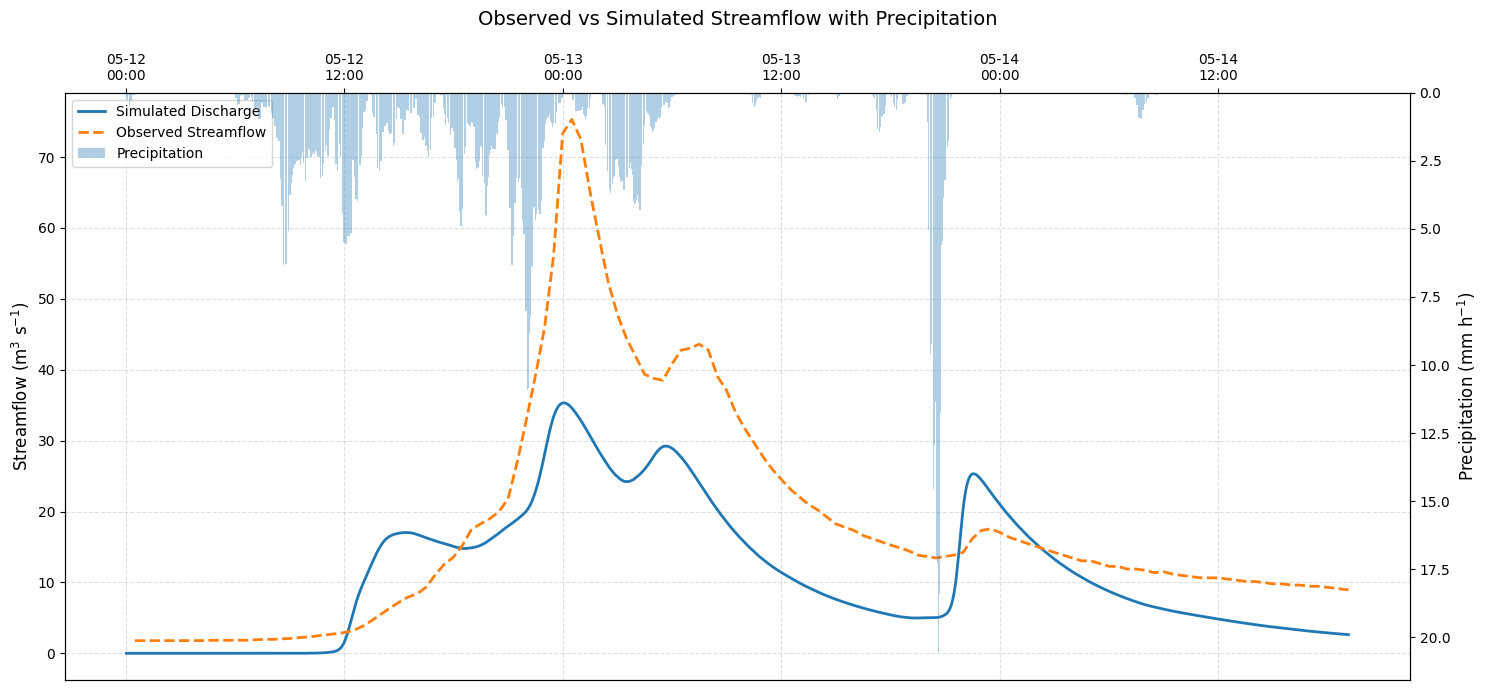

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

csv_file = r"C:\Repos\EF5-RTI\South_Toe_03463300\Output\ts.03463300.crest.csv"

df = pd.read_csv(csv_file)
df.columns = [c.strip() for c in df.columns]
df["Time"] = pd.to_datetime(df["Time"])

df["Discharge(m^3 s^-1)"] = pd.to_numeric(df["Discharge(m^3 s^-1)"], errors="coerce")
df["Observed(m^3 s^-1)"] = pd.to_numeric(df["Observed(m^3 s^-1)"], errors="coerce")
df["Precip(mm h^-1)"] = pd.to_numeric(df["Precip(mm h^-1)"], errors="coerce")

# set time index so interpolation uses actual timestamps
df = df.set_index("Time")

# interpolate observed values for plotting
df["Observed_interp"] = df["Observed(m^3 s^-1)"].interpolate(method="time")

fig, ax1 = plt.subplots(figsize=(15, 7))

ax1.plot(
    df.index,
    df["Discharge(m^3 s^-1)"],
    label="Simulated Discharge",
    linewidth=2
)

ax1.plot(
    df.index,
    df["Observed_interp"],
    label="Observed Streamflow",
    linewidth=2,
    linestyle="--"
)

ax1.set_ylabel("Streamflow (m$^3$ s$^{-1}$)", fontsize=12)
ax1.grid(True, linestyle="--", alpha=0.4)

ax2 = ax1.twinx()

if len(df) > 1:
    dt_days = (df.index[1] - df.index[0]).total_seconds() / 86400
    bar_width = dt_days * 0.9
else:
    bar_width = 0.01

ax2.bar(
    df.index,
    df["Precip(mm h^-1)"],
    width=bar_width,
    alpha=0.35,
    label="Precipitation"
)

ax2.set_ylabel("Precipitation (mm h$^{-1}$)", fontsize=12)
ax2.invert_yaxis()

ax1.xaxis.tick_top()
ax1.xaxis.set_label_position("top")
ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H:%M"))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Observed vs Simulated Streamflow with Precipitation", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

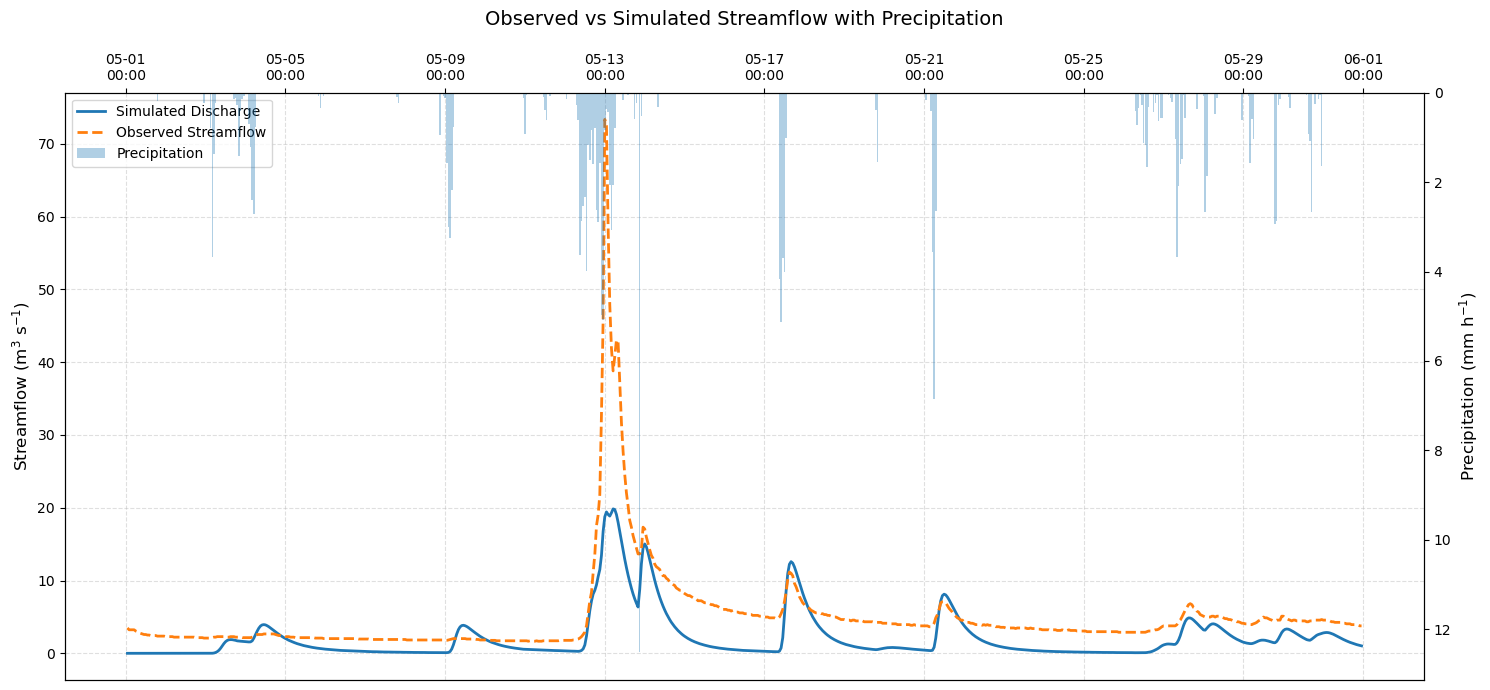

In [ ]:
import pandas as pd

csv_file = r"/home/clemasters/EF5-RTI/Output/03463300/crest/ts.03463300.crest.csv"

df = pd.read_csv(csv_file)
df.columns = [c.strip() for c in df.columns]
df["Time"] = pd.to_datetime(df["Time"])

df["Discharge(m^3 s^-1)"] = pd.to_numeric(df["Discharge(m^3 s^-1)"], errors="coerce")
df["Observed(m^3 s^-1)"] = pd.to_numeric(df["Observed(m^3 s^-1)"], errors="coerce")
df["Precip(mm h^-1)"] = pd.to_numeric(df["Precip(mm h^-1)"], errors="coerce")

# interpolate observed values for plotting
df["Observed_interp"] = df["Observed(m^3 s^-1)"].interpolate(method="time")

# Create subplot with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add simulated discharge trace
fig.add_trace(
    go.Scatter(
        x=df["Time"],
        y=df["Discharge(m^3 s^-1)"],
        mode="lines",
        name="Simulated Discharge",
        line=dict(width=2, color="blue", dash="dash")
    ),
    secondary_y=False,
)

# Add observed streamflow trace
fig.add_trace(
    go.Scatter(
        x=df["Time"],
        y=df["Observed_interp"],
        mode="lines",
        name="Observed Streamflow",
        line=dict(width=2, color="orange")
    ),
    secondary_y=False,
)

# Add precipitation trace (on secondary y-axis)
fig.add_trace(
    go.Bar(
        x=df["Time"],
        y=df["Precip(mm h^-1)"],
        name="Precipitation",
        opacity=0.35,
        marker_color="lightblue"
    ),
    secondary_y=True,
)

# Set x-axis title
fig.update_xaxes(title_text="Time")

# Set y-axes titles
fig.update_yaxes(title_text="Streamflow (m³/s)", secondary_y=False)
fig.update_yaxes(title_text="Precipitation (mm/h)", secondary_y=True)

# Invert precipitation axis
fig.update_yaxes(autorange="reversed", secondary_y=True)

# Update layout
fig.update_layout(
    title="CREST Model - Gage 03463300: Observed vs Simulated Streamflow with Precipitation",
    xaxis=dict(rangeslider_visible=True),
    template="plotly_white",
    hovermode="x unified",
    legend=dict(x=0.01, y=0.99),
    height=600, 
    width=1200
)

fig.show()

# Save as HTML file
html_file = "/home/clemasters/EF5-RTI/CREST_03463300_plot.html"
fig.write_html(html_file)
print(f"Plot saved as: {html_file}")

In [15]:
import pandas as pd

csv_file = r"/home/clemasters/EF5-RTI/Output/03463300/hp/ts.03463300.hp.csv"

df = pd.read_csv(csv_file)
df.columns = [c.strip() for c in df.columns]
df["Time"] = pd.to_datetime(df["Time"])

df["Discharge(m^3 s^-1)"] = pd.to_numeric(df["Discharge(m^3 s^-1)"], errors="coerce")
df["Observed(m^3 s^-1)"] = pd.to_numeric(df["Observed(m^3 s^-1)"], errors="coerce")
df["Precip(mm h^-1)"] = pd.to_numeric(df["Precip(mm h^-1)"], errors="coerce")

# interpolate observed values for plotting
df["Observed_interp"] = df["Observed(m^3 s^-1)"].interpolate(method="linear")

# Create subplot with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add simulated discharge trace
fig.add_trace(
    go.Scatter(
        x=df["Time"],
        y=df["Discharge(m^3 s^-1)"],
        mode="lines",
        name="Simulated Discharge",
        line=dict(width=2, color="blue", dash="dash")
    ),
    secondary_y=False,
)

# Add observed streamflow trace
fig.add_trace(
    go.Scatter(
        x=df["Time"],
        y=df["Observed_interp"],
        mode="lines",
        name="Observed Streamflow",
        line=dict(width=2, color="orange")
    ),
    secondary_y=False,
)

# Add precipitation trace (on secondary y-axis)
fig.add_trace(
    go.Bar(
        x=df["Time"],
        y=df["Precip(mm h^-1)"],
        name="Precipitation",
        opacity=0.35,
        marker_color="lightblue"
    ),
    secondary_y=True,
)

# Set x-axis title
fig.update_xaxes(title_text="Time")

# Set y-axes titles
fig.update_yaxes(title_text="Streamflow (m³/s)", secondary_y=False)
fig.update_yaxes(title_text="Precipitation (mm/h)", secondary_y=True)

# Invert precipitation axis
fig.update_yaxes(autorange="reversed", secondary_y=True)

# Update layout
fig.update_layout(
    title="HP Model - Gage 03463300: Observed vs Simulated Streamflow with Precipitation",
    xaxis=dict(rangeslider_visible=True),
    template="plotly_white",
    hovermode="x unified",
    legend=dict(x=0.01, y=0.99),
    height=600, 
    width=1200
)

fig.show()

# Save as HTML file
html_file = "/home/clemasters/EF5-RTI/HP_03463300_plot.html"
fig.write_html(html_file)
print(f"Plot saved as: {html_file}")

Plot saved as: /home/clemasters/EF5-RTI/HP_03463300_plot.html


In [11]:
import pandas as pd

csv_file = r"/home/clemasters/EF5-RTI/Output/03463300/sac/ts.03463300.sac.csv"

df = pd.read_csv(csv_file)
df.columns = [c.strip() for c in df.columns]
df["Time"] = pd.to_datetime(df["Time"])

df["Discharge(m^3 s^-1)"] = pd.to_numeric(df["Discharge(m^3 s^-1)"], errors="coerce")
df["Observed(m^3 s^-1)"] = pd.to_numeric(df["Observed(m^3 s^-1)"], errors="coerce")
df["Precip(mm h^-1)"] = pd.to_numeric(df["Precip(mm h^-1)"], errors="coerce")

# interpolate observed values for plotting
df["Observed_interp"] = df["Observed(m^3 s^-1)"].interpolate(method="linear")

# Create subplot with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add simulated discharge trace
fig.add_trace(
    go.Scatter(
        x=df["Time"],
        y=df["Discharge(m^3 s^-1)"],
        mode="lines",
        name="Simulated Discharge",
        line=dict(width=2, color="blue", dash="dash")
    ),
    secondary_y=False,
)

# Add observed streamflow trace
fig.add_trace(
    go.Scatter(
        x=df["Time"],
        y=df["Observed_interp"],
        mode="lines",
        name="Observed Streamflow",
        line=dict(width=2, color="orange")
    ),
    secondary_y=False,
)

# Add precipitation trace (on secondary y-axis)
fig.add_trace(
    go.Bar(
        x=df["Time"],
        y=df["Precip(mm h^-1)"],
        name="Precipitation",
        opacity=0.35,
        marker_color="lightblue"
    ),
    secondary_y=True,
)

# Set x-axis title
fig.update_xaxes(title_text="Time")

# Set y-axes titles
fig.update_yaxes(title_text="Streamflow (m³/s)", secondary_y=False)
fig.update_yaxes(title_text="Precipitation (mm/h)", secondary_y=True)

# Invert precipitation axis
fig.update_yaxes(autorange="reversed", secondary_y=True)

# Update layout
fig.update_layout(
    title="SAC Model - Gage 03463300: Observed vs Simulated Streamflow with Precipitation",
    xaxis=dict(rangeslider_visible=True),
    template="plotly_white",
    hovermode="x unified",
    legend=dict(x=0.01, y=0.99),
    height=600, 
    width=1200
)

fig.show()

# Save as HTML file
html_file = "/home/clemasters/EF5-RTI/SAC_03463300_plot.html"
fig.write_html(html_file)
print(f"Plot saved as: {html_file}")

Plot saved as: /home/clemasters/EF5-RTI/SAC_03463300_plot.html


In [14]:
import pandas as pd

csv_file = r"/home/clemasters/EF5-RTI/Output/03463300/crest/ts.03463300.crest.csv"

df = pd.read_csv(csv_file)
df.columns = [c.strip() for c in df.columns]
df["Time"] = pd.to_datetime(df["Time"])

df["Discharge(m^3 s^-1)"] = pd.to_numeric(df["Discharge(m^3 s^-1)"], errors="coerce")
df["Observed(m^3 s^-1)"] = pd.to_numeric(df["Observed(m^3 s^-1)"], errors="coerce")
df["Precip(mm h^-1)"] = pd.to_numeric(df["Precip(mm h^-1)"], errors="coerce")

# interpolate observed values for plotting
df["Observed_interp"] = df["Observed(m^3 s^-1)"].interpolate(method="linear")

# Create subplot with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add simulated discharge trace
fig.add_trace(
    go.Scatter(
        x=df["Time"],
        y=df["Discharge(m^3 s^-1)"],
        mode="lines",
        name="Simulated Discharge",
        line=dict(width=2, color="blue", dash="dash")
    ),
    secondary_y=False,
)

# Add observed streamflow trace
fig.add_trace(
    go.Scatter(
        x=df["Time"],
        y=df["Observed_interp"],
        mode="lines",
        name="Observed Streamflow",
        line=dict(width=2, color="orange")
    ),
    secondary_y=False,
)

# Add precipitation trace (on secondary y-axis)
fig.add_trace(
    go.Bar(
        x=df["Time"],
        y=df["Precip(mm h^-1)"],
        name="Precipitation",
        opacity=0.35,
        marker_color="lightblue"
    ),
    secondary_y=True,
)

# Set x-axis title
fig.update_xaxes(title_text="Time")

# Set y-axes titles
fig.update_yaxes(title_text="Streamflow (m³/s)", secondary_y=False)
fig.update_yaxes(title_text="Precipitation (mm/h)", secondary_y=True)

# Invert precipitation axis
fig.update_yaxes(autorange="reversed", secondary_y=True)

# Update layout
fig.update_layout(
    title="CREST Model - Gage 03463300: Observed vs Simulated Streamflow with Precipitation",
    xaxis=dict(rangeslider_visible=True),
    template="plotly_white",
    hovermode="x unified",
    legend=dict(x=0.01, y=0.99),
    height=600, 
    width=1200
)

fig.show()

# Save as HTML file
html_file = "/home/clemasters/EF5-RTI/CREST_03463300_plot.html"
fig.write_html(html_file)
print(f"Plot saved as: {html_file}")

Plot saved as: /home/clemasters/EF5-RTI/CREST_03463300_plot.html


In [10]:
import pandas as pd

csv_file = r"/home/clemasters/EF5-RTI/Output/04282780/crest/ts.04282780.crest.csv"

df = pd.read_csv(csv_file)
df.columns = [c.strip() for c in df.columns]
df["Time"] = pd.to_datetime(df["Time"])

df["Discharge(m^3 s^-1)"] = pd.to_numeric(df["Discharge(m^3 s^-1)"], errors="coerce")
df["Observed(m^3 s^-1)"] = pd.to_numeric(df["Observed(m^3 s^-1)"], errors="coerce")
df["Precip(mm h^-1)"] = pd.to_numeric(df["Precip(mm h^-1)"], errors="coerce")

# interpolate observed values for plotting
df["Observed_interp"] = df["Observed(m^3 s^-1)"].interpolate(method="linear")

# Create subplot with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add simulated discharge trace
fig.add_trace(
    go.Scatter(
        x=df["Time"],
        y=df["Discharge(m^3 s^-1)"],
        mode="lines",
        name="Simulated Discharge",
        line=dict(width=2, color="blue", dash="dash")
    ),
    secondary_y=False,
)

# Add observed streamflow trace
fig.add_trace(
    go.Scatter(
        x=df["Time"],
        y=df["Observed_interp"],
        mode="lines",
        name="Observed Streamflow",
        line=dict(width=2, color="orange")
    ),
    secondary_y=False,
)

# Add precipitation trace (on secondary y-axis)
fig.add_trace(
    go.Bar(
        x=df["Time"],
        y=df["Precip(mm h^-1)"],
        name="Precipitation",
        opacity=0.35,
        marker_color="lightblue"
    ),
    secondary_y=True,
)

# Set x-axis title
fig.update_xaxes(title_text="Time")

# Set y-axes titles
fig.update_yaxes(title_text="Streamflow (m³/s)", secondary_y=False)
fig.update_yaxes(title_text="Precipitation (mm/h)", secondary_y=True)

# Invert precipitation axis
fig.update_yaxes(autorange="reversed", secondary_y=True)

# Update layout
fig.update_layout(
    title="CREST Model - Gage 04282780: Observed vs Simulated Streamflow with Precipitation",
    xaxis=dict(rangeslider_visible=True),
    template="plotly_white",
    hovermode="x unified",
    legend=dict(x=0.01, y=0.99),
    height=600, 
    width=1200
)

fig.show()

# Save as HTML file
html_file = "/home/clemasters/EF5-RTI/CREST_04282780_plot.html"
fig.write_html(html_file)
print(f"Plot saved as: {html_file}")

Plot saved as: /home/clemasters/EF5-RTI/CREST_04282780_plot.html


In [12]:
import pandas as pd

csv_file = r"/home/clemasters/EF5-RTI/Output/04282780/hp/ts.04282780.hp.csv"

df = pd.read_csv(csv_file)
df.columns = [c.strip() for c in df.columns]
df["Time"] = pd.to_datetime(df["Time"])

df["Discharge(m^3 s^-1)"] = pd.to_numeric(df["Discharge(m^3 s^-1)"], errors="coerce")
df["Observed(m^3 s^-1)"] = pd.to_numeric(df["Observed(m^3 s^-1)"], errors="coerce")
df["Precip(mm h^-1)"] = pd.to_numeric(df["Precip(mm h^-1)"], errors="coerce")

# interpolate observed values for plotting
df["Observed_interp"] = df["Observed(m^3 s^-1)"].interpolate(method="linear")

# Create subplot with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add simulated discharge trace
fig.add_trace(
    go.Scatter(
        x=df["Time"],
        y=df["Discharge(m^3 s^-1)"],
        mode="lines",
        name="Simulated Discharge",
        line=dict(width=2, color="blue", dash="dash")
    ),
    secondary_y=False,
)

# Add observed streamflow trace
fig.add_trace(
    go.Scatter(
        x=df["Time"],
        y=df["Observed_interp"],
        mode="lines",
        name="Observed Streamflow",
        line=dict(width=2, color="orange")
    ),
    secondary_y=False,
)

# Add precipitation trace (on secondary y-axis)
fig.add_trace(
    go.Bar(
        x=df["Time"],
        y=df["Precip(mm h^-1)"],
        name="Precipitation",
        opacity=0.35,
        marker_color="lightblue"
    ),
    secondary_y=True,
)

# Set x-axis title
fig.update_xaxes(title_text="Time")

# Set y-axes titles
fig.update_yaxes(title_text="Streamflow (m³/s)", secondary_y=False)
fig.update_yaxes(title_text="Precipitation (mm/h)", secondary_y=True)

# Invert precipitation axis
fig.update_yaxes(autorange="reversed", secondary_y=True)

# Update layout
fig.update_layout(
    title="HP Model - Gage 04282780: Observed vs Simulated Streamflow with Precipitation",
    xaxis=dict(rangeslider_visible=True),
    template="plotly_white",
    hovermode="x unified",
    legend=dict(x=0.01, y=0.99),
    height=600, 
    width=1200
)

fig.show()

# Save as HTML file
html_file = "/home/clemasters/EF5-RTI/HP_04282780_plot.html"
fig.write_html(html_file)
print(f"Plot saved as: {html_file}")

Plot saved as: /home/clemasters/EF5-RTI/HP_04282780_plot.html


In [16]:
import pandas as pd

csv_file = r"/home/clemasters/EF5-RTI/Output/04282780/sac/ts.04282780.sac.csv"

df = pd.read_csv(csv_file)
df.columns = [c.strip() for c in df.columns]
df["Time"] = pd.to_datetime(df["Time"])

df["Discharge(m^3 s^-1)"] = pd.to_numeric(df["Discharge(m^3 s^-1)"], errors="coerce")
df["Observed(m^3 s^-1)"] = pd.to_numeric(df["Observed(m^3 s^-1)"], errors="coerce")
df["Precip(mm h^-1)"] = pd.to_numeric(df["Precip(mm h^-1)"], errors="coerce")

# interpolate observed values for plotting
df["Observed_interp"] = df["Observed(m^3 s^-1)"].interpolate(method="linear")

# Create subplot with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add simulated discharge trace
fig.add_trace(
    go.Scatter(
        x=df["Time"],
        y=df["Discharge(m^3 s^-1)"],
        mode="lines",
        name="Simulated Discharge",
        line=dict(width=2, color="blue", dash="dash")
    ),
    secondary_y=False,
)

# Add observed streamflow trace
fig.add_trace(
    go.Scatter(
        x=df["Time"],
        y=df["Observed_interp"],
        mode="lines",
        name="Observed Streamflow",
        line=dict(width=2, color="orange")
    ),
    secondary_y=False,
)

# Add precipitation trace (on secondary y-axis)
fig.add_trace(
    go.Bar(
        x=df["Time"],
        y=df["Precip(mm h^-1)"],
        name="Precipitation",
        opacity=0.35,
        marker_color="lightblue"
    ),
    secondary_y=True,
)

# Set x-axis title
fig.update_xaxes(title_text="Time")

# Set y-axes titles
fig.update_yaxes(title_text="Streamflow (m³/s)", secondary_y=False)
fig.update_yaxes(title_text="Precipitation (mm/h)", secondary_y=True)

# Invert precipitation axis
fig.update_yaxes(autorange="reversed", secondary_y=True)

# Update layout
fig.update_layout(
    title="SAC Model - Gage 04282780: Observed vs Simulated Streamflow with Precipitation",
    xaxis=dict(rangeslider_visible=True),
    template="plotly_white",
    hovermode="x unified",
    legend=dict(x=0.01, y=0.99),
    height=600, 
    width=1200
)

fig.show()

# Save as HTML file
html_file = "/home/clemasters/EF5-RTI/SAC_04282780_plot.html"
fig.write_html(html_file)
print(f"Plot saved as: {html_file}")

Plot saved as: /home/clemasters/EF5-RTI/SAC_04282780_plot.html


# Multi-Model Comparison Plot

Compare all three hydrological models (CREST, SAC-SMA, HP) on a single interactive plot with observed data and precipitation.

In [2]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
import numpy as np

# Define base directory and automatically discover all available gages
base_output_dir = Path("/home/clemasters/EF5-RTI/Output")

# Get all available gage directories
available_gages = [d.name for d in base_output_dir.iterdir() if d.is_dir()]
available_gages.sort()  # Sort for consistent processing order

print(f"Found {len(available_gages)} gages with model outputs:")
for gage in available_gages:
    print(f"  - {gage}")
print("=" * 60)

# Color scheme for models
model_colors = {
    "CREST": "#1f77b4",      # Blue
    "SAC-SMA": "#ff7f0e",    # Orange  
    "HP": "#2ca02c",         # Green
    "Observed": "#000000"    # Black
}

def create_multi_model_plot(gage_id):
    """Create multi-model comparison plot for a single gage."""
    
    print(f"\nCreating multi-model comparison plot for gage {gage_id}")
    print("-" * 40)
    
    # Define paths to model output files
    model_files = {
        "CREST": base_output_dir / gage_id / "crest" / f"ts.{gage_id}.crest.csv",
        "SAC-SMA": base_output_dir / gage_id / "sac" / f"ts.{gage_id}.sac.csv", 
        "HP": base_output_dir / gage_id / "hp" / f"ts.{gage_id}.hp.csv"
    }
    
    # Load and process data from all models
    model_data = {}
    for model_name, file_path in model_files.items():
        if file_path.exists():
            print(f"  ✓ Loading {model_name} data")
            df = pd.read_csv(file_path)
            
            # Clean column names
            df.columns = [c.strip() for c in df.columns]
            
            # Convert time column
            df["Time"] = pd.to_datetime(df["Time"])
            
            # Convert numeric columns
            df["Discharge(m^3 s^-1)"] = pd.to_numeric(df["Discharge(m^3 s^-1)"], errors="coerce")
            df["Observed(m^3 s^-1)"] = pd.to_numeric(df["Observed(m^3 s^-1)"], errors="coerce") 
            df["Precip(mm h^-1)"] = pd.to_numeric(df["Precip(mm h^-1)"], errors="coerce")
            
            # Store processed data
            model_data[model_name] = df
            
            # Print data summary
            valid_discharge = df["Discharge(m^3 s^-1)"].notna().sum()
            total_points = len(df)
            print(f"    - {total_points} time steps, {valid_discharge} valid discharge values")
        else:
            print(f"  ✗ {model_name} file not found: {file_path}")
    
    if not model_data:
        print(f"  ⚠ No model data found for gage {gage_id}")
        return None
    
    # Create subplot with secondary y-axis for precipitation
    fig = make_subplots(
        specs=[[{"secondary_y": True}]],
        subplot_titles=[f"Multi-Model Hydrological Comparison - USGS Gage {gage_id}"]
    )
    
    # Add model discharge traces (dashed lines)
    for model_name, df in model_data.items():
        fig.add_trace(
            go.Scatter(
                x=df["Time"],
                y=df["Discharge(m^3 s^-1)"],
                mode="lines",
                name=f"{model_name} Simulated",
                line=dict(width=2.5, color=model_colors[model_name], dash="dash"),
                hovertemplate=f"<b>{model_name}</b><br>" +
                             "Time: %{x}<br>" +
                             "Discharge: %{y:.2f} m³/s<extra></extra>"
            ),
            secondary_y=False,
        )
    
    # Add observed streamflow (solid black line)
    reference_df = list(model_data.values())[0]
    
    # Interpolate observed values for better visualization
    observed_interp = reference_df["Observed(m^3 s^-1)"].interpolate(method="linear")
    
    fig.add_trace(
        go.Scatter(
            x=reference_df["Time"],
            y=observed_interp,
            mode="lines",
            name="USGS Observed",
            line=dict(width=3, color=model_colors["Observed"]),
            hovertemplate="<b>Observed</b><br>" +
                         "Time: %{x}<br>" +
                         "Discharge: %{y:.2f} m³/s<extra></extra>"
        ),
        secondary_y=False,
    )
    
    # Add precipitation bars (inverted on secondary axis)
    fig.add_trace(
        go.Bar(
            x=reference_df["Time"],
            y=reference_df["Precip(mm h^-1)"],
            name="Precipitation",
            opacity=0.4,
            marker_color="lightblue",
            width=3600000,  # 1 hour in milliseconds for better bar width
            hovertemplate="<b>Precipitation</b><br>" +
                         "Time: %{x}<br>" +
                         "Intensity: %{y:.1f} mm/h<extra></extra>"
        ),
        secondary_y=True,
    )
    
    # Customize axes
    fig.update_xaxes(title_text="Time", showgrid=True, gridwidth=1, gridcolor="lightgray")
    fig.update_yaxes(
        title_text="Streamflow (m³/s)", 
        secondary_y=False,
        showgrid=True, 
        gridwidth=1, 
        gridcolor="lightgray"
    )
    fig.update_yaxes(
        title_text="Precipitation Rate (mm/h)", 
        secondary_y=True,
        autorange="reversed",  # Invert precipitation axis
        showgrid=False
    )
    
    # Update layout with enhanced styling
    fig.update_layout(
        title={
            "text": f"EF5 Multi-Model Streamflow Comparison<br>" + 
                   f"<sub>USGS Gage {gage_id} - CREST vs SAC-SMA vs HP Models</sub>",
            "x": 0.5,
            "font": {"size": 16}
        },
        xaxis=dict(
            rangeslider_visible=True,
            rangeslider=dict(thickness=0.05)
        ),
        template="plotly_white",
        hovermode="x unified",
        legend=dict(
            x=0.01, 
            y=0.99,
            bgcolor="rgba(255,255,255,0.8)",
            bordercolor="lightgray",
            borderwidth=1
        ),
        height=700, 
        width=1400,
        margin=dict(t=100, b=80, l=80, r=80)
    )
    
    # Add annotations with model performance info
    # Calculate basic statistics
    stats_text = []
    reference_observed = reference_df["Observed(m^3 s^-1)"].dropna()
    
    for model_name, df in model_data.items():
        simulated = df["Discharge(m^3 s^-1)"].dropna()
        if len(simulated) > 0:
            mean_sim = simulated.mean()
            max_sim = simulated.max()
            stats_text.append(f"{model_name}: Mean={mean_sim:.1f} m³/s, Max={max_sim:.1f} m³/s")
    
    if len(reference_observed) > 0:
        mean_obs = reference_observed.mean()
        max_obs = reference_observed.max()
        stats_text.append(f"Observed: Mean={mean_obs:.1f} m³/s, Max={max_obs:.1f} m³/s")
    
    # Add statistics annotation
    fig.add_annotation(
        text="<br>".join(stats_text),
        xref="paper", yref="paper",
        x=0.02, y=0.02,
        showarrow=False,
        font=dict(size=10, color="darkblue"),
        bgcolor="rgba(255,255,255,0.8)",
        bordercolor="lightgray",
        borderwidth=1,
        align="left"
    )
    
    # Display the plot
    fig.show()
    
    # Save as HTML file in the gage's specific Output directory
    html_file = base_output_dir / gage_id / f"Multi_Model_Comparison_{gage_id}_plot.html"
    fig.write_html(html_file)
    print(f"  ✓ Plot saved as: {html_file}")
    print(f"  ✓ Models compared: {', '.join(model_data.keys())}")
    
    return html_file

# Create plots for all available gages
print("\n" + "=" * 60)
print("GENERATING MULTI-MODEL COMPARISON PLOTS")
print("=" * 60)

plot_files = []
for gage_id in available_gages:
    html_file = create_multi_model_plot(gage_id)
    if html_file:
        plot_files.append(html_file)

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Created {len(plot_files)} multi-model comparison plots:")
for plot_file in plot_files:
    print(f"  - {plot_file}")
print(f"\nPlots saved in respective gage directories under: /home/clemasters/EF5-RTI/Output/")

Found 2 gages with model outputs:
  - 03463300
  - 04282780

GENERATING MULTI-MODEL COMPARISON PLOTS

Creating multi-model comparison plot for gage 03463300
----------------------------------------
  ✓ Loading CREST data
    - 2183 time steps, 2183 valid discharge values
  ✓ Loading SAC-SMA data
    - 2183 time steps, 2183 valid discharge values
  ✓ Loading HP data
    - 2183 time steps, 2183 valid discharge values


  ✓ Plot saved as: /home/clemasters/EF5-RTI/Output/03463300/Multi_Model_Comparison_03463300_plot.html
  ✓ Models compared: CREST, SAC-SMA, HP

Creating multi-model comparison plot for gage 04282780
----------------------------------------
  ✓ Loading CREST data
    - 2183 time steps, 2183 valid discharge values
  ✓ Loading SAC-SMA data
    - 2183 time steps, 2183 valid discharge values
  ✓ Loading HP data
    - 2183 time steps, 2183 valid discharge values


  ✓ Plot saved as: /home/clemasters/EF5-RTI/Output/04282780/Multi_Model_Comparison_04282780_plot.html
  ✓ Models compared: CREST, SAC-SMA, HP

SUMMARY
Created 2 multi-model comparison plots:
  - /home/clemasters/EF5-RTI/Output/03463300/Multi_Model_Comparison_03463300_plot.html
  - /home/clemasters/EF5-RTI/Output/04282780/Multi_Model_Comparison_04282780_plot.html

Plots saved in respective gage directories under: /home/clemasters/EF5-RTI/Output/
